In [9]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pandas as pd
import muon as mu
import scanpy as sc
import scirpy as ir
np.random.seed(42)
import random
random.seed(42)
import sys
# sys.path.append(r"E:\Python code\Machine learning\JupyterNote\Bio_CRC\Data processing\functions")
sys.path.append(r"/ihome/ylee/yiz133/Code/Data processing/functions/")
import mdata_utils
import TCR_embedings

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.sparse import issparse
import importlib

In [11]:
# importlib.reload(TCR_embedings)

In [12]:
path = '/ix1/ylee/Yifan_Zhang/Code_data/external/EAE/'
filename = "EAE_HV1000_per_GSM.h5mu"
mdata_ori = mu.read(path + filename)

In [13]:
mdata = mdata_ori.copy()
mdata

MuData object with n_obs × n_vars = 132088 × 4836
  obs:	'GSE', 'GSM', 'VDJ_1_cdr3_aa', 'VDJ_1_j_call', 'VDJ_1_v_call', 'VJ_1_cdr3_aa', 'VJ_1_j_call', 'VJ_1_v_call', 'cell_type', 'condition', 'sample_id', 'state'
  2 modalities
    airr:	132088 x 0
      obs:	'sample_id', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id', 'clone_id_size', 'clonal_expansion', 'sample', 'tissue', 'condition'
      obsm:	'airr', 'chain_indices'
    gex:	132088 x 4836
      obs:	'batch', 'condition', 'sample_id', 'tissue', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts', 'CD4score', 'CD8score', 'Tregscore', 'Th17score', 'cell_type', 'IFN_stimscore', 'Activationscore', 'Exhaustscore', 'Mem_Naivescore', 'state', 'GSM', 'sample', 'date', 'mouse_BC', 'leiden', 'GSE'
      var:	'gene_ids', 'feature_types'
      uns:	'GSE_colors', 'X_umap_harmony', 'cell_type_colors', 'leiden', 'neighbors', 'neighbors_harmony', 'pca', 'state_colors', 'tissue_colors', 'umap'
      obsm:	'X_pca', 'X_pca_harmony', 'X_umap', 'X_umap_harmony'
      varm:	'PCs'
      obsp:	'connectivities', 'distances', 'neighbors_harmony_connectivities', 'neighbors_harmony_distances'

In [14]:
mdata.obs['sample_id'].value_counts()

sample_id
mouse1    19998
mouse2    19760
mixed     11608
6_3        8697
O3         8119
Y2         7839
6_2        7712
O2         7385
6_4        7291
6_1        6324
O1         5784
Y1         4065
Y3         3972
5_7        3534
5_5        3468
5_6        3348
5_8        3070
5_3          63
5_4          51
Name: count, dtype: int64

In [15]:
mdata.obs['GSE'].value_counts()

GSE
LEE          43558
GSE188320    39758
GSE182747    37164
GSE293883    11097
GSE178085      511
Name: count, dtype: int64

# Settings

In [16]:
Batch_corrected   = True
train_frac        = 0.7
if_test_isolated  = True            # True = hold out a full GSE as test set

gene_PCA      = 'X_pca_harmony'  if Batch_corrected else 'X_pca'
gene_Umap     = 'X_umap_harmony' if Batch_corrected else 'X_umap'
neighbors_key = 'neighbors_harmony' if Batch_corrected else 'neighbors'

# Data preview

In [17]:
mdata['gex'].obs['Tissue_group'] = (
    mdata['gex'].obs['tissue'].apply(lambda x: x if x == 'CNS' else 'non-CNS')
)
mdata['gex'].obs['Tissue_group'].value_counts()

Tissue_group
non-CNS    72532
CNS        49229
Name: count, dtype: int64

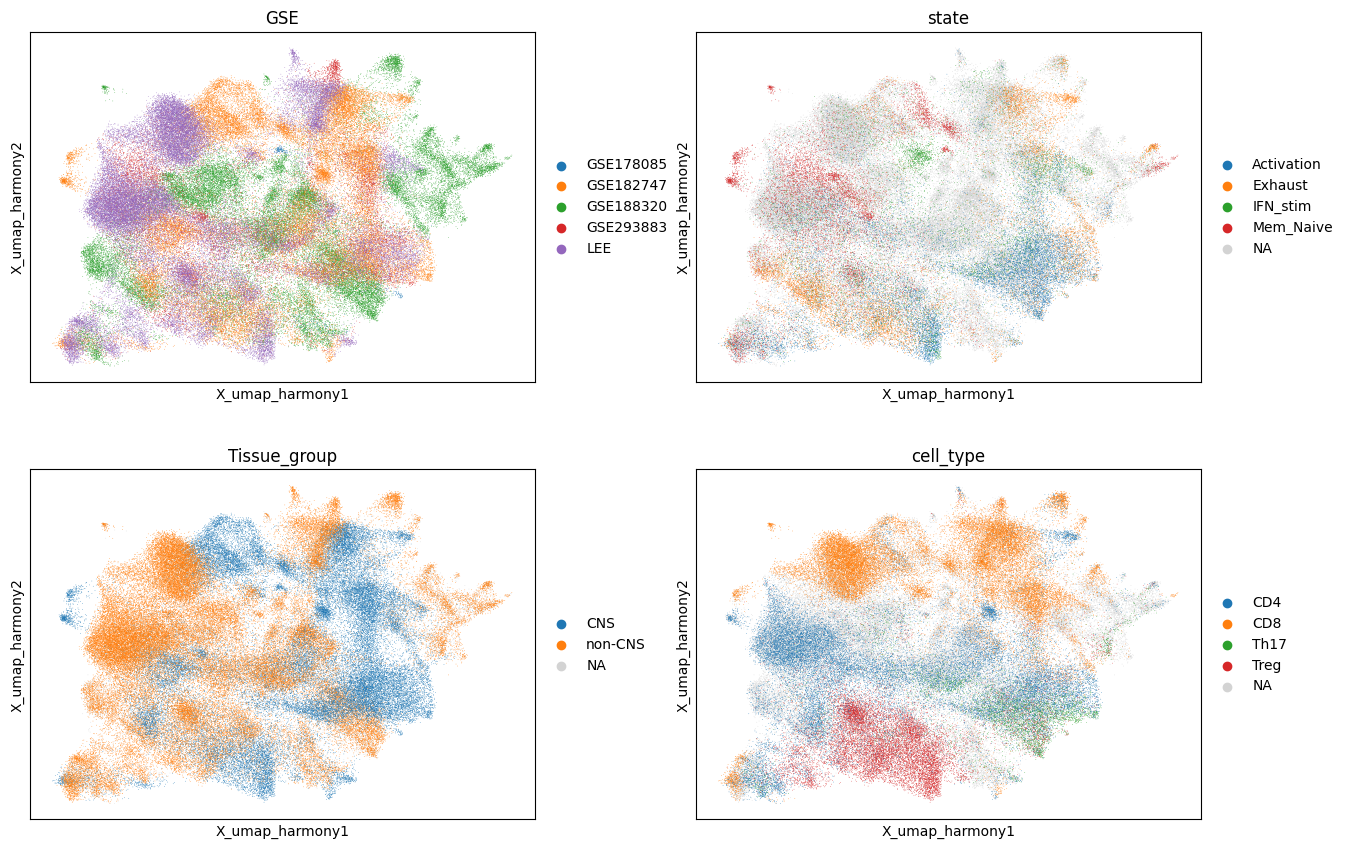

In [18]:
sc.pl.embedding(
    mdata['gex'], basis=gene_Umap, neighbors_key=neighbors_key,
    color=['GSE', 'state', 'Tissue_group', 'cell_type'], ncols=2, wspace=0.2
)

# Subsets

## One cell per clone

In [19]:
# Select one representative cell per clonotype (CCA notebook approach)
airr_obs = mdata['airr'].obs.copy()
clone_id_col = airr_obs['clone_id']
if hasattr(clone_id_col, 'cat'):
    clone_id_col = clone_id_col.astype(str)
airr_obs['_clone_id_str'] = clone_id_col

expanded = airr_obs[airr_obs['clone_id_size'] > 1].dropna(subset=['_clone_id_str'])
sampled_expanded_idx = (
    expanded
    .groupby('_clone_id_str', observed=True)
    .sample(n=1, random_state=42)
    .index
)

single_idx = airr_obs[airr_obs['clone_id_size'] == 1].index
keep_idx   = sampled_expanded_idx.append(single_idx)

mdata = mdata[keep_idx].copy()
print(f"Expanded clones: {len(expanded)} cells -> {len(sampled_expanded_idx)} (1 per clone)")
print(f"Single clones:   {len(single_idx)}")
print(f"Total after dedup: {mdata.n_obs} cells")

Expanded clones: 63871 cells -> 8465 (1 per clone)
Single clones:   67597
Total after dedup: 76062 cells


In [20]:
mdata

MuData object with n_obs × n_vars = 76062 × 4836
  obs:	'GSE', 'GSM', 'VDJ_1_cdr3_aa', 'VDJ_1_j_call', 'VDJ_1_v_call', 'VJ_1_cdr3_aa', 'VJ_1_j_call', 'VJ_1_v_call', 'cell_type', 'condition', 'sample_id', 'state'
  2 modalities
    airr:	76062 x 0
      obs:	'sample_id', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id', 'clone_id_size', 'clonal_expansion', 'sample', 'tissue', 'condition'
      obsm:	'airr', 'chain_indices'
    gex:	76062 x 4836
      obs:	'batch', 'condition', 'sample_id', 'tissue', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts', 'CD4score', 'CD8score', 'Tregscore', 'Th17score', 'cell_type', 'IFN_stimscore', 'Activationscore', 'Exhaustscore', 'Mem_Naivescore', 'state', 'GSM', 'sample', 'date', 'mouse_BC', 'leiden', 'GSE', 'Tissue_group'
      var:	'gene_ids', 'feature_types'
      uns:	'GSE_colors', 'X_umap_harmony', 'cell_type_colors', 'leiden', 'neighbors', 'neighbors_harmony', 'pca', 'state_colors', 'tissue_colors', 'umap', 'Tissue_group_colors'
      obsm:	'X_pca', 'X_pca_harmony', 'X_umap', 'X_umap_harmony'
      varm:	'PCs'
      obsp:	'connectivities', 'distances', 'neighbors_harmony_connectivities', 'neighbors_harmony_distances'

# Embed TCR AA into vector

In [21]:
# both chains
tcr_aa_obs      = ['VDJ_1_cdr3_aa', 'VJ_1_cdr3_aa']
tcr_cat_features = ['VDJ_1_j_call', 'VDJ_1_v_call', 'VJ_1_j_call', 'VJ_1_v_call']

In [22]:
# Atchley factors for the 20 amino acids
atchley_factors = {
    'A': [ 0.591, -1.302, -0.733,  1.570, -0.146],
    'R': [ 1.538,  0.055,  1.502,  0.440,  2.897],
    'N': [ 0.945,  0.828,  1.299, -0.169,  0.933],
    'D': [ 1.050,  0.302, -3.656, -0.259, -3.242],
    'C': [-1.343,  0.465, -0.862, -1.020, -0.255],
    'Q': [ 0.931,  0.179, -3.005, -0.503, -1.853],
    'E': [ 1.357,  0.113, -3.242, -0.339, -2.192],
    'G': [ 0.384,  1.652,  1.330,  1.045,  2.064],
    'H': [ 0.336, -0.417, -1.673, -1.474, -0.078],
    'I': [-1.239, -0.547,  2.131,  0.393,  0.816],
    'L': [-1.019, -0.987, -1.505,  1.266, -0.912],
    'K': [ 1.831, -0.561,  0.533, -0.277,  1.648],
    'M': [-0.663, -1.524,  2.219, -1.005,  1.212],
    'F': [-1.006, -0.590,  1.891, -0.397,  0.412],
    'P': [ 0.189,  2.081, -1.628,  0.421, -1.392],
    'S': [ 0.228,  1.399, -4.760,  0.670, -2.647],
    'T': [ 0.032,  2.213, -1.455,  0.311, -0.259],
    'W': [-0.595,  0.009,  0.672, -2.128, -0.184],
    'Y': [ 0.260,  0.830,  3.097, -0.838,  1.512],
    'V': [-1.337, -0.279, -0.544,  1.242, -1.262],
}

In [23]:
# Vectorize each TCR AA column: length filter, Atchley encoding, pairwise interactions, composition
for aa_col in tcr_aa_obs:
    lengths      = TCR_embedings.compute_sequence_lengths(mdata, aa_col)
    lengths_mask = (lengths > 10) & (lengths < 20)
    len_key      = f'{aa_col}_length'
    mdata        = mdata[lengths_mask]
    mdata.obs[len_key] = lengths[lengths_mask]
    print(f"Stored {aa_col} lengths in mdata.obs['{len_key}']")

    encoded  = TCR_embedings.vectorize_tcr_column(mdata, aa_col, atchley_factors)
    key_name = f'X_{aa_col}_atchley'
    mdata.obsm[key_name] = encoded
    print(f"Stored {aa_col} Atchley vectors in mdata.obsm['{key_name}'] with shape {encoded.shape}")

    atchley_positions = encoded.shape[1] // 5
    pairwise_key      = f'X_{aa_col}_atchley_pairwise'
    if atchley_positions > 1:
        encoded_reshaped  = encoded.reshape(encoded.shape[0], atchley_positions, 5)
        pairwise_features = []
        for pos in range(atchley_positions - 1):
            current = encoded_reshaped[:, pos, :]
            nxt     = encoded_reshaped[:, pos + 1, :]
            outer   = (current[:, :, None] * nxt[:, None, :]).reshape(encoded.shape[0], -1)
            pairwise_features.append(outer)
        pairwise_matrix = np.concatenate(pairwise_features, axis=1)
    else:
        pairwise_matrix = np.zeros((encoded.shape[0], 0))
    mdata.obsm[pairwise_key] = pairwise_matrix
    print(f"Stored {aa_col} pairwise Atchley in mdata.obsm['{pairwise_key}'] with shape {pairwise_matrix.shape}")

    aa_comp  = TCR_embedings.compute_aa_composition_matrix(mdata, aa_col)
    comp_key = f'X_{aa_col}_composition'
    mdata.obsm[comp_key] = aa_comp
    print(f"Stored {aa_col} AA composition in mdata.obsm['{comp_key}'] with shape {aa_comp.shape}\n")

Stored VDJ_1_cdr3_aa lengths in mdata.obs['VDJ_1_cdr3_aa_length']
Stored VDJ_1_cdr3_aa Atchley vectors in mdata.obsm['X_VDJ_1_cdr3_aa_atchley'] with shape (60876, 100)
Stored VDJ_1_cdr3_aa pairwise Atchley in mdata.obsm['X_VDJ_1_cdr3_aa_atchley_pairwise'] with shape (60876, 475)
Stored VDJ_1_cdr3_aa AA composition in mdata.obsm['X_VDJ_1_cdr3_aa_composition'] with shape (60876, 20)

Stored VJ_1_cdr3_aa lengths in mdata.obs['VJ_1_cdr3_aa_length']
Stored VJ_1_cdr3_aa Atchley vectors in mdata.obsm['X_VJ_1_cdr3_aa_atchley'] with shape (43417, 100)
Stored VJ_1_cdr3_aa pairwise Atchley in mdata.obsm['X_VJ_1_cdr3_aa_atchley_pairwise'] with shape (43417, 475)
Stored VJ_1_cdr3_aa AA composition in mdata.obsm['X_VJ_1_cdr3_aa_composition'] with shape (43417, 20)



In [24]:
# One-hot encode categorical TCR features (V/J gene calls)
for cat_col in tcr_cat_features:
    encoded = TCR_embedings.onehot_encode_categorical(mdata, cat_col)
    mdata.obsm[cat_col] = encoded

VDJ_1_j_call: 12 unique categories + 1 unknown = 13 dimensions
VDJ_1_v_call: 24 unique categories + 1 unknown = 25 dimensions
VJ_1_j_call: 42 unique categories + 1 unknown = 43 dimensions
VJ_1_v_call: 105 unique categories + 1 unknown = 106 dimensions


## Concatenate TCR features

In [25]:
arrs_tcr = [v for v in mdata.obsm.values()]
view_tcr = np.concatenate(arrs_tcr, axis=1)

for chain in tcr_aa_obs:
    view_tcr = np.concatenate(
        [view_tcr, mdata.obs[chain + '_length'].to_numpy().reshape(-1, 1)], axis=1
    )

view_tcr = np.concatenate(
    [view_tcr, mdata['airr'].obs['clone_id_size'].to_numpy().reshape(-1, 1)], axis=1
)

print(f"TCR feature matrix: {view_tcr.shape}")

# Store TCR embeddings
scaler   = StandardScaler()
view_tcr = scaler.fit_transform(view_tcr)
mdata.obsm['tcr_embs'] = view_tcr

TCR feature matrix: (43417, 1382)


# Prepare views for CCA

In [26]:
# Extract TCR embeddings
view_tcr = mdata.obsm['tcr_embs']

# Gene expression: get raw matrix and apply PCA (same as CCA notebook)
X_gene = mdata['gex'].X
if issparse(X_gene):
    X_gene = X_gene.toarray()
view_gene = np.asarray(X_gene, dtype=float)
view_tcr  = np.asarray(view_tcr, dtype=float)

pca_gene      = PCA(n_components=50, random_state=42)
view_gene     = pca_gene.fit_transform(view_gene)
var_explained = pca_gene.explained_variance_ratio_
print(f"Gene PCA cumulative variance (50 PCs): {var_explained.cumsum()[-1]:.3f}")

Gene PCA cumulative variance (50 PCs): 0.628


In [27]:
print(f"view_gene: {view_gene.shape}")
print(f"view_tcr:  {view_tcr.shape}")

view_gene: (43417, 50)
view_tcr:  (43417, 1382)


# CCA

## Train / test split

In [56]:
mdata.obs['GSM'].value_counts()

GSM
0605      15557
0516       7961
SPLEEN     4376
batch6     2371
batch9     1931
Y2         1756
O3         1519
BRAIN      1422
batch8     1384
batch7     1359
O2         1229
Y1         1003
O1          864
Y3          684
Wt_men        1
Wt_par        0
Name: count, dtype: int64

In [57]:
dim_cca = 5
mdata.obs['set'] = ''

train_mask = mdata.obs['GSM'].isin(['0516', 'batch7', 'Y1', 'O1',])
test_mask  = ~mdata.obs['GSM'].isin(['0516', 'batch7', 'Y1', 'O1',])

view_gene_train = view_gene[train_mask]
view_gene_test  = view_gene[test_mask]
view_tcr_train  = view_tcr[train_mask]
view_tcr_test   = view_tcr[test_mask]

print(f"Train: {view_gene_train.shape[0]}  Test: {view_gene_test.shape[0]}")
print(f"Latent dims (dim_cca): {dim_cca}")
print(mdata.obs['set'].value_counts())
print(mdata[test_mask].obs['GSE'].value_counts())

Train: 11187  Test: 32230
Latent dims (dim_cca): 5
set
    43417
Name: count, dtype: int64
GSE
LEE          15557
GSE293883     5798
GSE188320     5686
GSE182747     5188
GSE178085        1
Name: count, dtype: int64


## Fit rCCA

In [59]:
importlib.reload(TCR_embedings)

dim_cca = 3
cca = TCR_embedings.rCCA(n_components=dim_cca, alpha_x=5, alpha_y=5)

view_gene_c_train, view_tcr_c_train = cca.fit_transform(view_gene_train, view_tcr_train)
view_gene_c_test,  view_tcr_c_test  = cca.transform(view_gene_test, view_tcr_test)

print(f"Train canonical variates: {view_gene_c_train.shape}")
print(f"Test  canonical variates: {view_gene_c_test.shape}")

Train canonical variates: (11187, 3)
Test  canonical variates: (32230, 3)


In [60]:
# Combine canonical variates for the full dataset
view_gene_c = np.zeros((mdata.n_obs, dim_cca))
view_tcr_c  = np.zeros((mdata.n_obs, dim_cca))
view_gene_c[train_mask] = view_gene_c_train
view_gene_c[test_mask]  = view_gene_c_test
view_tcr_c[train_mask]  = view_tcr_c_train
view_tcr_c[test_mask]   = view_tcr_c_test

# Store CV scores in mdata
cv_list = []
for i in range(dim_cca):
    mdata['gex'].obs[f'DCCA_CV_{i}'] = view_gene_c[:, i]
    mdata['gex'].obs[f'DCCA_CV_TCR_{i}'] = view_tcr_c[:, i]

# Store CCA weights
# cca.x_weights_ = cca.coef_x_
# cca.y_weights_ = cca.coef_y_
# mdata.uns['cca_x_weights'] = cca.x_weights_
# mdata.uns['cca_y_weights'] = cca.y_weights_

# Plots

## Train vs test correlation

In [61]:
corr_train, corr_test = TCR_embedings.train_test_corr(
    view_gene_c_train, view_tcr_c_train,
    view_gene_c_test,  view_tcr_c_test
)

Canonical Correlations Comparison:
Component       Train Corr      Test Corr       Difference     
Component 1      0.4785          0.2693          0.2092         
Component 2      0.3855          0.2347          0.1507         
Component 3      0.3711          0.1814          0.1897         


(0.0, 1.0)

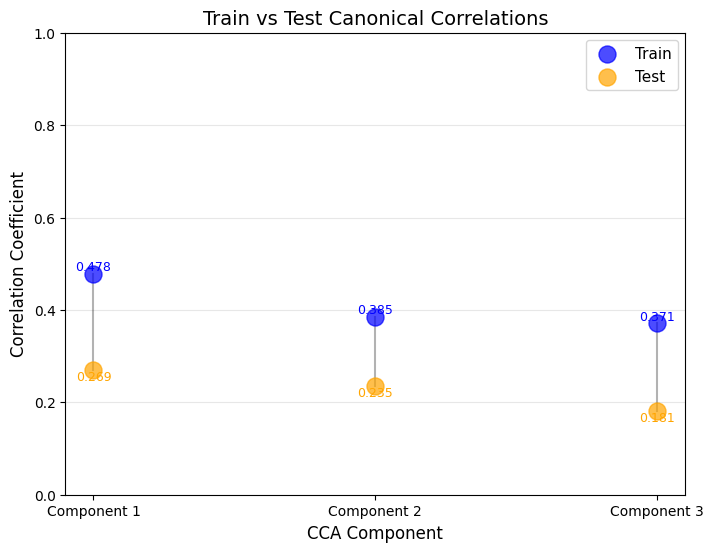

In [62]:
ax = TCR_embedings.plot_train_test_corr(corr_train, corr_test)
ax.set_ylim(0, 1)

## Scatter: gene vs TCR canonical variates

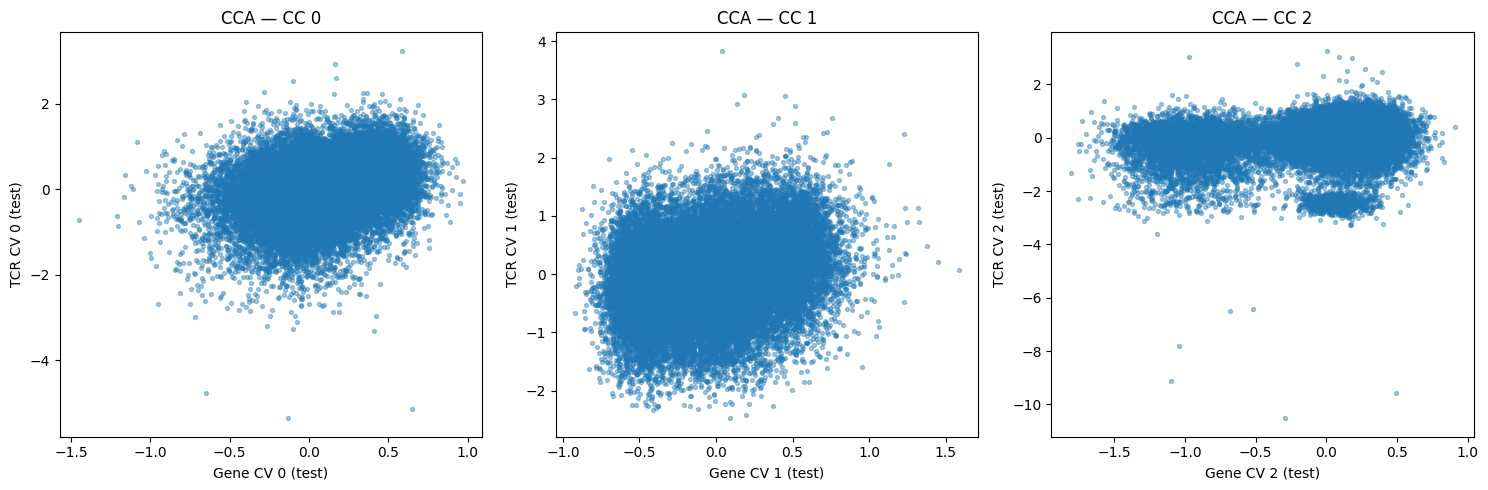

In [63]:
fig, axes = plt.subplots(1, dim_cca, figsize=(5 * dim_cca, 5))
if dim_cca == 1:
    axes = [axes]
for i, ax in enumerate(axes):
    ax.scatter(view_gene_c_test[:, i], view_tcr_c_test[:, i], alpha=0.4, s=8)
    ax.set_xlabel(f'Gene CV {i} (test)')
    ax.set_ylabel(f'TCR CV {i} (test)')
    ax.set_title(f'CCA — CC {i}')
plt.tight_layout()
plt.show()

## UMAP: CV scores

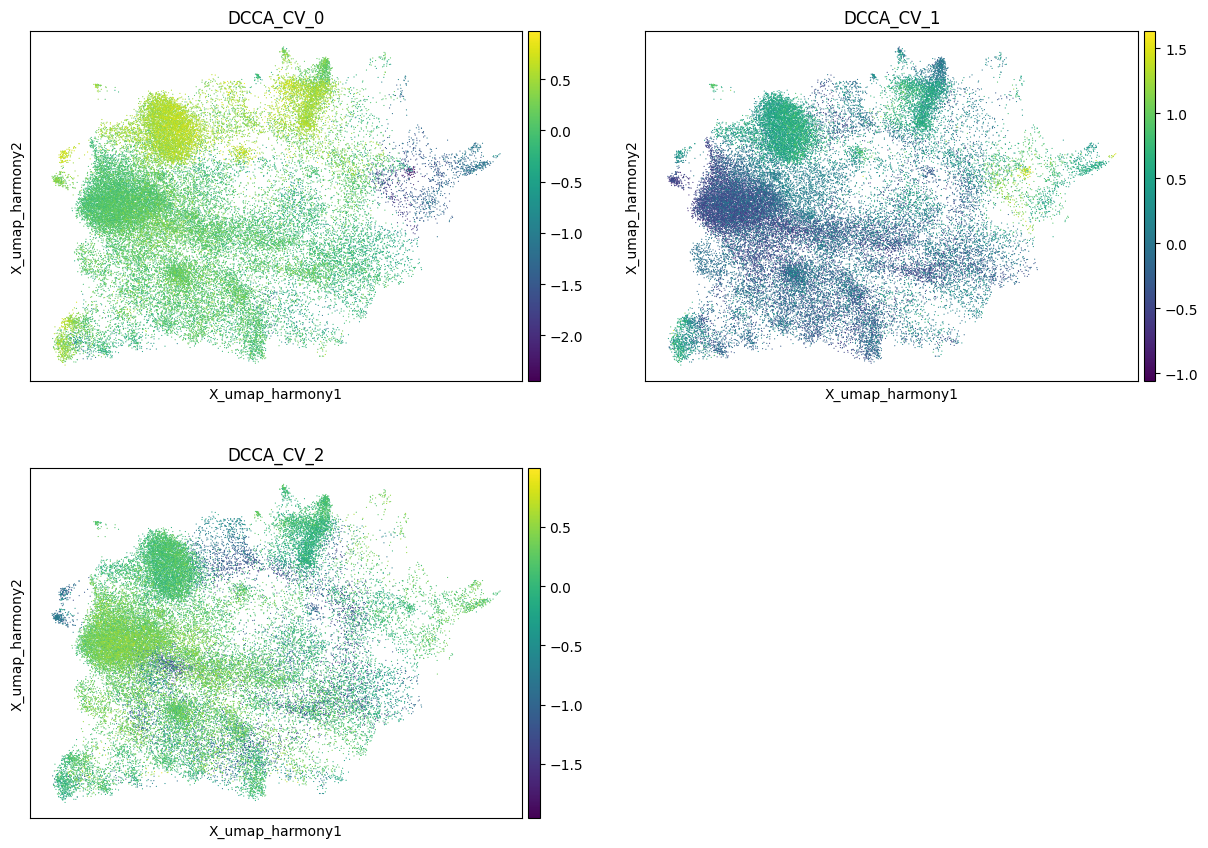

In [64]:
for i in range(dim_cca):
    # cv_list.append(f'DCCA_CV_TCR_{i}')
    cv_list.append(f'DCCA_CV_{i}')
    
sc.pl.embedding(
    mdata['gex'], basis=gene_Umap, neighbors_key=neighbors_key,
    color=cv_list, ncols=2
)

# CV score analysis

## Kruskal-Wallis: does each biological label differ across CVs?

In [65]:
mdata

MuData object with n_obs × n_vars = 43417 × 4836
  obs:	'GSE', 'GSM', 'VDJ_1_cdr3_aa', 'VDJ_1_j_call', 'VDJ_1_v_call', 'VJ_1_cdr3_aa', 'VJ_1_j_call', 'VJ_1_v_call', 'cell_type', 'condition', 'sample_id', 'state', 'VDJ_1_cdr3_aa_length', 'VJ_1_cdr3_aa_length', 'set'
  obsm:	'X_VDJ_1_cdr3_aa_atchley', 'X_VDJ_1_cdr3_aa_atchley_pairwise', 'X_VDJ_1_cdr3_aa_composition', 'X_VJ_1_cdr3_aa_atchley', 'X_VJ_1_cdr3_aa_atchley_pairwise', 'X_VJ_1_cdr3_aa_composition', 'VDJ_1_j_call', 'VDJ_1_v_call', 'VJ_1_j_call', 'VJ_1_v_call', 'tcr_embs'
  2 modalities
    airr:	43417 x 0
      obs:	'sample_id', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id', 'clone_id_size', 'clonal_expansion', 'sample', 'tissue', 'condition'
      obsm:	'airr', 'chain_indices'
    gex:	43417 x 4836
      obs:	'batch', 'condition', 'sample_id', 'tissue', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts', 'CD4score', 'CD8score', 'Tregscore', 'Th17score', 'cell_type', 'IFN_stimscore', 'Activationscore', 'Exhaustscore', 'Mem_Naivescore', 'state', 'GSM', 'sample', 'date', 'mouse_BC', 'leiden', 'GSE', 'Tissue_group', 'DCCA_CV_0', 'DCCA_CV_TCR_0', 'DCCA_CV_1', 'DCCA_CV_TCR_1', 'DCCA_CV_2', 'DCCA_CV_TCR_2', 'cloned', 'CNS_score', 'SPL_score'
      var:	'gene_ids', 'feature_types'
      uns:	'GSE_colors', 'X_umap_harmony', 'cell_type_colors', 'leiden', 'neighbors', 'neighbors_harmony', 'pca', 'state_colors', 'tissue_colors', 'umap', 'Tissue_group_colors', 'rank_genes_groups'
      obsm:	'X_pca', 'X_pca_harmony', 'X_umap', 'X_umap_harmony'
      varm:	'PCs'
      obsp:	'connectivities', 'distances', 'neighbors_harmony_connectivities', 'neighbors_harmony_distances'

In [66]:
mdata['gex'].obs['state'] = mdata.obs['state']
mdata['gex'].obs['cloned'] = mdata['airr'].obs['clone_id_size'].reindex(mdata.obs_names).gt(1).fillna(False)


In [67]:
# Step 1 — Kruskal-Wallis / Point-biserial: does this column matter at all?

from scipy.stats import kruskal, pointbiserialr
import pandas as pd

composition_cols = ['cell_type', 'state', 'cloned', 'Tissue_group']

# for obs in composition_cols:
#     mdata['gex'].obs[obs] = mdata.obs[obs]
    
records = []
# CV_from = "DCCA_CV_"
CV_from = "DCCA_CV_TCR_"


for i in range(dim_cca):
    col = CV_from + str(i)
    scores = mdata['gex'].obs[col].dropna()
    idx = scores.index

    for c in composition_cols:
        cats = mdata['gex'].obs.loc[idx, c].dropna()
        shared_idx = scores.index.intersection(cats.index)
        s = scores.loc[shared_idx]
        g = cats.loc[shared_idx]

        unique_cats = g.unique()

        if len(unique_cats) == 2:
            # binary → point-biserial r
            binary = (g == unique_cats[0]).astype(int)
            r, p = pointbiserialr(binary, s)
            records.append(dict(cv=col, obs_col=c, test='pointbiserial',
                                statistic=r, pval=p, categories=list(unique_cats)))

        elif len(unique_cats) > 2:
            # multi-category → Kruskal-Wallis H
            groups = [s[g == cat].values for cat in unique_cats]
            groups = [g for g in groups if len(g) > 1]
            if len(groups) >= 2:
                H, p = kruskal(*groups)
                records.append(dict(cv=col, obs_col=c, test='kruskal',
                                    statistic=H, pval=p, categories=list(unique_cats)))

df_stats = pd.DataFrame(records)

# FDR correction
from statsmodels.stats.multitest import multipletests
_, df_stats['pval_fdr'], _, _ = multipletests(df_stats['pval'], method='fdr_bh')
df_stats = df_stats.sort_values(['cv', 'pval_fdr'])
print(df_stats[['cv', 'obs_col', 'test', 'statistic', 'pval', 'pval_fdr']])

               cv       obs_col           test    statistic           pval  \
0   DCCA_CV_TCR_0     cell_type        kruskal  2772.964207   0.000000e+00   
2   DCCA_CV_TCR_0        cloned  pointbiserial    -0.129289  3.569591e-161   
3   DCCA_CV_TCR_0  Tissue_group  pointbiserial    -0.066054   5.167358e-41   
1   DCCA_CV_TCR_0         state        kruskal   109.726682   1.256478e-23   
4   DCCA_CV_TCR_1     cell_type        kruskal  2087.040491   0.000000e+00   
6   DCCA_CV_TCR_1        cloned  pointbiserial     0.025098   1.692652e-07   
7   DCCA_CV_TCR_1  Tissue_group  pointbiserial    -0.022022   7.933400e-06   
5   DCCA_CV_TCR_1         state        kruskal    16.073509   1.095304e-03   
11  DCCA_CV_TCR_2  Tissue_group  pointbiserial    -0.185910  1.351968e-316   
10  DCCA_CV_TCR_2        cloned  pointbiserial    -0.079182   2.447640e-61   
8   DCCA_CV_TCR_2     cell_type        kruskal   204.811837   3.849438e-44   
9   DCCA_CV_TCR_2         state        kruskal    30.856184   9.

In [68]:
# Step 2 — Spearman per category label: which specific label drives it?
from scipy.stats import spearmanr

records_cat = []

for i in range(3):
    col = CV_from + str(i)
    scores = mdata['gex'].obs[col].dropna()

    for c in composition_cols:
        cats = mdata['gex'].obs.loc[scores.index, c].dropna()
        shared = scores.index.intersection(cats.index)

        for cat_val in cats.loc[shared].unique():
            binary = (cats.loc[shared] == cat_val).astype(int)
            r, p = spearmanr(scores.loc[shared], binary)
            records_cat.append(dict(cv=col, obs_col=c, category=cat_val,
                                    spearman_r=r, pval=p))

df_cat = pd.DataFrame(records_cat)
_, df_cat['pval_fdr'], _, _ = multipletests(df_cat['pval'], method='fdr_bh')
df_cat = df_cat.sort_values('spearman_r', key=abs, ascending=False)
print(df_cat.head(20))

               cv       obs_col   category  spearman_r           pval  \
1   DCCA_CV_TCR_0     cell_type        CD8    0.329639   0.000000e+00   
13  DCCA_CV_TCR_1     cell_type        CD8    0.284199   0.000000e+00   
0   DCCA_CV_TCR_0     cell_type        CD4   -0.207121  7.436576e-242   
12  DCCA_CV_TCR_1     cell_type        CD4   -0.206566  1.526793e-240   
34  DCCA_CV_TCR_2  Tissue_group        CNS   -0.182639  1.931900e-305   
35  DCCA_CV_TCR_2  Tissue_group    non-CNS    0.182639  1.931900e-305   
9   DCCA_CV_TCR_0        cloned      False    0.118850  2.470900e-136   
8   DCCA_CV_TCR_0        cloned       True   -0.118850  2.470900e-136   
3   DCCA_CV_TCR_0     cell_type       Treg   -0.110272   6.700898e-69   
32  DCCA_CV_TCR_2        cloned       True   -0.089543   5.445223e-78   
33  DCCA_CV_TCR_2        cloned      False    0.089543   5.445223e-78   
15  DCCA_CV_TCR_1     cell_type       Treg   -0.085876   2.145791e-42   
25  DCCA_CV_TCR_2     cell_type        CD8   -0.084

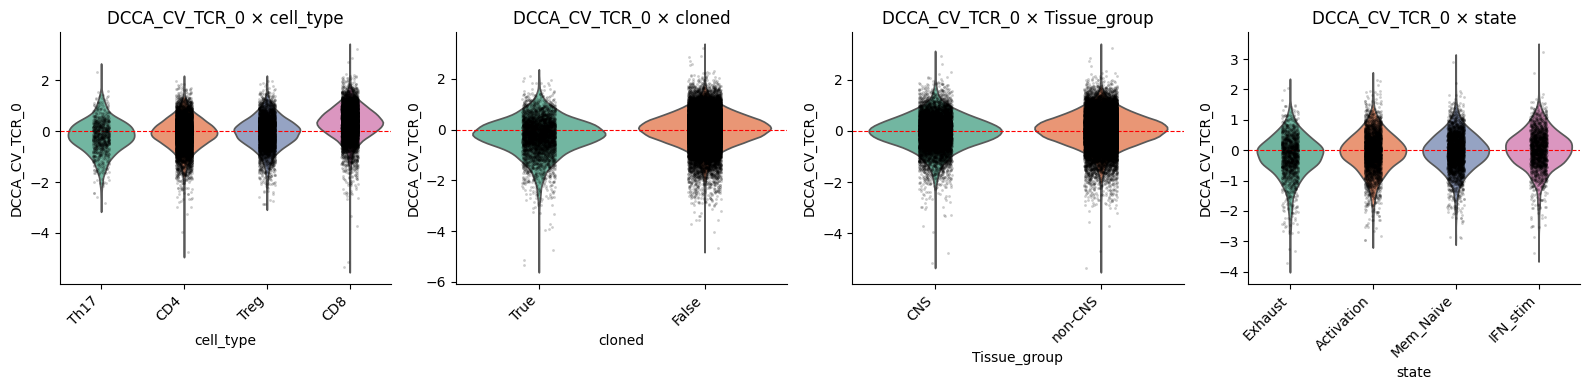

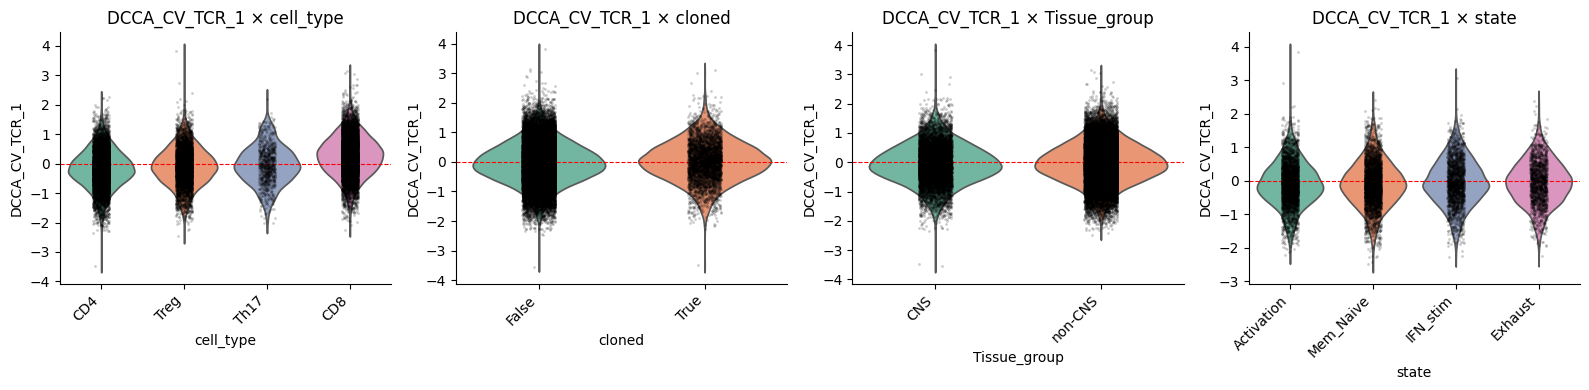

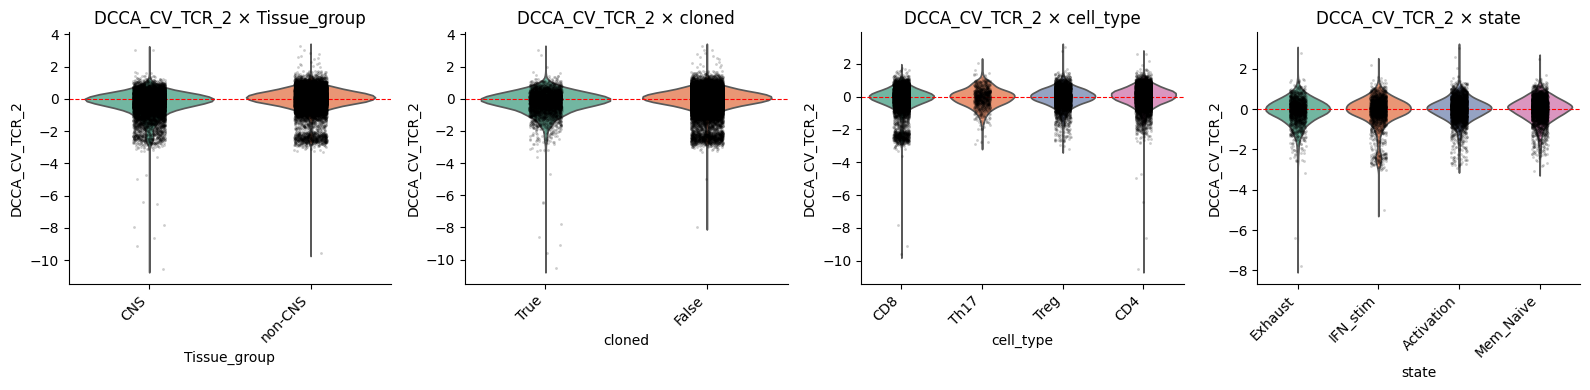

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

# pick significant columns per CV from df_stats
sig = df_stats[df_stats['pval_fdr'] < 0.05]

for i in range(dim_cca):
    col = CV_from + str(i)
    sig_cols = sig[sig['cv'] == col]['obs_col'].tolist()

    if not sig_cols:
        continue

    fig, axes = plt.subplots(1, len(sig_cols), figsize=(4 * len(sig_cols), 4))
    if len(sig_cols) == 1:
        axes = [axes]

    for ax, c in zip(axes, sig_cols):
        mdata['gex'].obs[c] = mdata['gex'].obs[c].astype('category').cat.remove_unused_categories()
        plot_df = mdata['gex'].obs[[col, c]].dropna()
        order = plot_df.groupby(c)[col].median().sort_values().index

        sns.violinplot(data=plot_df, x=c, y=col, order=order,
                       inner=None, palette='Set2', ax=ax)
        sns.stripplot(data=plot_df, x=c, y=col, order=order,
                      color='black', alpha=0.2, size=2, ax=ax)
        ax.axhline(0, color='red', linestyle='--', linewidth=0.8)
        ax.set_title(f'{col} × {c}')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        ax.spines[['top', 'right']].set_visible(False)
        # ax.set_ylim([-0.5, 0.5])

    plt.tight_layout()
    plt.savefig(f'{col}_category_association.pdf', bbox_inches='tight')
    plt.show()

In [70]:
## pairwise subset comparison
from scipy.stats import mannwhitneyu
from itertools import combinations

records_posthoc = []

for i in range(dim_cca):
    col = CV_from + str(i)
    scores = mdata['gex'].obs[col].dropna()

    # only run on columns that passed Step 1 FDR
    sig_cols = df_stats[
        (df_stats['cv'] == col) & (df_stats['pval_fdr'] < 0.05)
    ]['obs_col'].tolist()

    for c in sig_cols:
        cats = mdata['gex'].obs.loc[scores.index, c].dropna()
        shared = scores.index.intersection(cats.index)
        s = scores.loc[shared]
        g = cats.loc[shared]

        unique_cats = g.unique()

        for cat_a, cat_b in combinations(unique_cats, 2):
            vals_a = s[g == cat_a].values
            vals_b = s[g == cat_b].values

            if len(vals_a) < 3 or len(vals_b) < 3:
                continue

            U, p = mannwhitneyu(vals_a, vals_b, alternative='two-sided')

            # effect size: rank-biserial correlation
            n_a, n_b = len(vals_a), len(vals_b)
            rbc = 1 - (2 * U) / (n_a * n_b)

            records_posthoc.append(dict(
                cv       = col,
                obs_col  = c,
                cat_a    = cat_a,
                cat_b    = cat_b,
                U        = U,
                pval     = p,
                rbc      = rbc,   # effect size: -1 to +1
            ))

df_posthoc = pd.DataFrame(records_posthoc)
_, df_posthoc['pval_fdr'], _, _ = multipletests(df_posthoc['pval'], method='fdr_bh')
df_posthoc = df_posthoc.sort_values('pval_fdr')
print(df_posthoc[df_posthoc['pval_fdr'] < 0.05])

               cv       obs_col       cat_a      cat_b            U  \
0   DCCA_CV_TCR_0     cell_type         CD4        CD8   26653347.5   
14  DCCA_CV_TCR_1     cell_type         CD4        CD8   28228946.5   
4   DCCA_CV_TCR_0     cell_type         CD8       Treg   35607699.0   
28  DCCA_CV_TCR_2  Tissue_group         CNS    non-CNS  123029928.5   
18  DCCA_CV_TCR_1     cell_type         CD8       Treg   34042971.0   
6   DCCA_CV_TCR_0        cloned        True      False   69526303.0   
3   DCCA_CV_TCR_0     cell_type         CD8       Th17    6530592.0   
29  DCCA_CV_TCR_2        cloned        True      False   74439211.0   
30  DCCA_CV_TCR_2     cell_type         CD4        CD8   49627763.5   
7   DCCA_CV_TCR_0  Tissue_group         CNS    non-CNS  147699941.5   
17  DCCA_CV_TCR_1     cell_type         CD8       Th17    5631036.0   
11  DCCA_CV_TCR_0         state     Exhaust   IFN_stim    1574023.5   
34  DCCA_CV_TCR_2     cell_type         CD8       Treg   24049903.0   
12  DC

In [71]:
# for i in range(dim_cca):
#     col = CV_from + str(i)
#     sig_cols = df_posthoc[
#         (df_posthoc['cv'] == col) & (df_posthoc['pval_fdr'] < 0.05)
#     ]['obs_col'].unique()

#     for c in sig_cols:
#         sub = df_posthoc[(df_posthoc['cv'] == col) & (df_posthoc['obs_col'] == c)]
#         cats = pd.Index(
#             pd.concat([sub['cat_a'], sub['cat_b']]).unique()
#         )

#         # pivot effect size (rbc) into a square matrix
#         mat = pd.DataFrame(np.nan, index=cats, columns=cats)
#         for _, row in sub.iterrows():
#             # mat.loc[row.cat_a, row.cat_b] = row.rbc
#             # mat.loc[row.cat_b, row.cat_a] = -row.rbc  # antisymmetric
            
#             mat.loc[row.cat_a, row.cat_b] = abs(row.rbc)
#             mat.loc[row.cat_b, row.cat_a] = abs(row.rbc)  # symmetric
            
            
#         np.fill_diagonal(mat.values, 0)

#         # significance mask
#         sig_mat = pd.DataFrame(False, index=cats, columns=cats)
#         for _, row in sub.iterrows():
#             sig = row.pval_fdr < 0.05
#             sig_mat.loc[row.cat_a, row.cat_b] = sig
#             sig_mat.loc[row.cat_b, row.cat_a] = sig

#         fig, ax = plt.subplots(figsize=(0.6 * len(cats) + 2, 0.6 * len(cats) + 2))
#         sns.heatmap(mat.astype(float), annot=True, fmt='.2f', center=0,
#                     cmap='RdBu_r', vmin= 0, vmax=1,
#                     mask=~sig_mat,         # grey out non-significant pairs
#                     linewidths=0.5, ax=ax)
#         ax.set_title(f'{col} × {c}\nrank-biserial correlation (FDR<0.05 only)', fontsize=10)
#         plt.tight_layout()
#         plt.savefig(f'{col}_{c}_posthoc_heatmap.pdf', bbox_inches='tight')
#         plt.show()

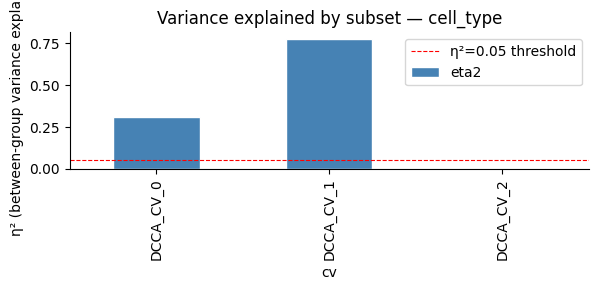

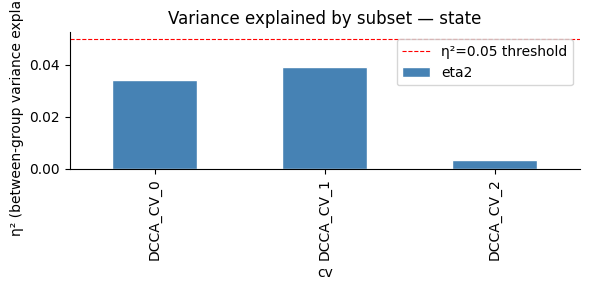

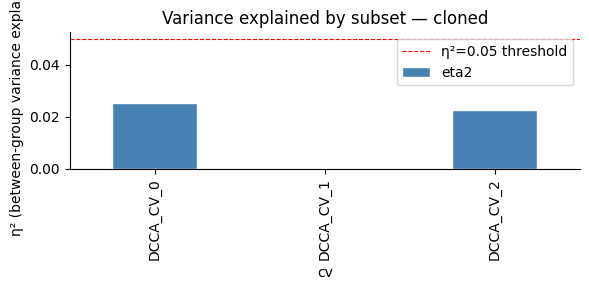

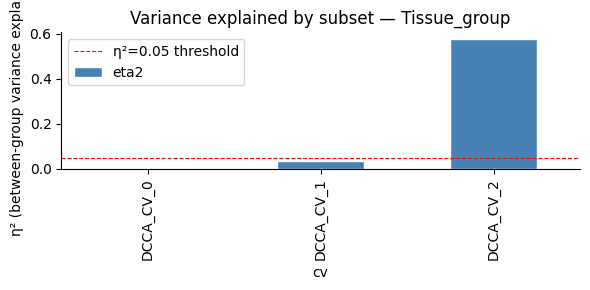

In [72]:
# 1. variance explained by each CV across subsets
#    = between-group variance / total variance per CV

records_var_gex = []
for i in range(dim_cca):
    col = "DCCA_CV_" + str(i)
    scores = mdata['gex'].obs[col].dropna()
    total_var = scores.var()

    for c in composition_cols:
        labels = mdata['gex'].obs.loc[scores.index, c].dropna()
        shared = scores.index.intersection(labels.index)

        group_means = scores.loc[shared].groupby(labels.loc[shared]).mean()
        grand_mean  = scores.loc[shared].mean()

        # between-group variance (eta squared)
        between_var = (
            labels.loc[shared].value_counts() *
            (group_means - grand_mean) ** 2
        ).sum() / len(shared)

        eta2 = between_var / total_var

        records_var_gex.append(dict(cv=col, obs_col=c, eta2=eta2))

df_var_gex = pd.DataFrame(records_var_gex)

# plot eta2 per CV per obs column
for c in composition_cols:
    sub = df_var_gex[df_var_gex['obs_col'] == c].set_index('cv')['eta2']
    fig, ax = plt.subplots(figsize=(6, 3))
    sub.plot.bar(ax=ax, color='steelblue', edgecolor='white')
    ax.set_ylabel('η² (between-group variance explained)')
    ax.set_title(f'Variance explained by subset — {c}')
    ax.axhline(0.05, color='red', linestyle='--', linewidth=0.8,
               label='η²=0.05 threshold')
    ax.legend()
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.savefig(f'eta2_gex_{c}.pdf', bbox_inches='tight')
    plt.show()

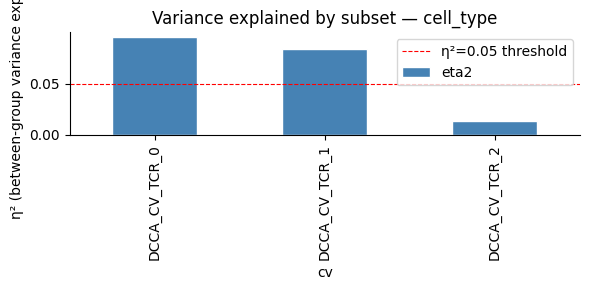

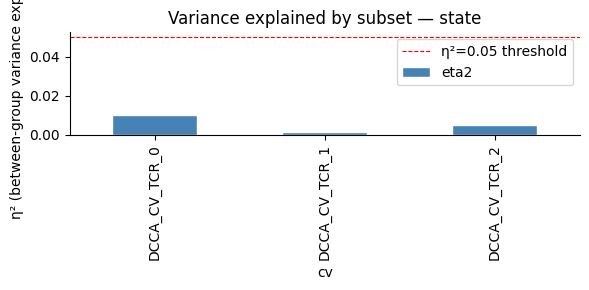

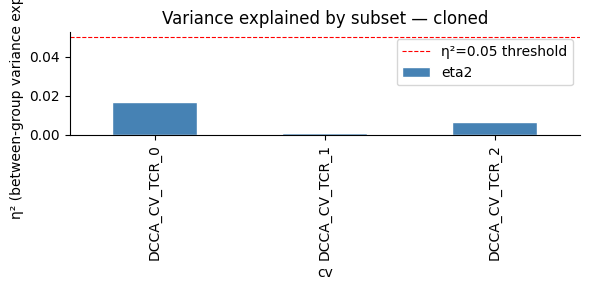

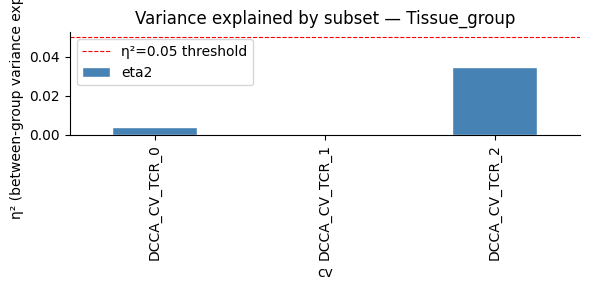

In [73]:
# 1. variance explained by each CV across subsets
#    = between-group variance / total variance per CV

records_var = []
for i in range(dim_cca):
    col = "DCCA_CV_TCR_" + str(i)
    scores = mdata['gex'].obs[col].dropna()
    total_var = scores.var()

    for c in composition_cols:
        labels = mdata['gex'].obs.loc[scores.index, c].dropna()
        shared = scores.index.intersection(labels.index)

        group_means = scores.loc[shared].groupby(labels.loc[shared]).mean()
        grand_mean  = scores.loc[shared].mean()

        # between-group variance (eta squared)
        between_var = (
            labels.loc[shared].value_counts() *
            (group_means - grand_mean) ** 2
        ).sum() / len(shared)

        eta2 = between_var / total_var

        records_var.append(dict(cv=col, obs_col=c, eta2=eta2))

df_var = pd.DataFrame(records_var)

# plot eta2 per CV per obs column
for c in composition_cols:
    sub = df_var[df_var['obs_col'] == c].set_index('cv')['eta2']
    fig, ax = plt.subplots(figsize=(6, 3))
    sub.plot.bar(ax=ax, color='steelblue', edgecolor='white')
    ax.set_ylabel('η² (between-group variance explained)')
    ax.set_title(f'Variance explained by subset — {c}')
    ax.axhline(0.05, color='red', linestyle='--', linewidth=0.8,
               label='η²=0.05 threshold')
    ax.legend()
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.savefig(f'eta2_{c}.pdf', bbox_inches='tight')
    plt.show()

In [74]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import pandas as pd
import numpy as np

records_ovr = []

for i in range(dim_cca):
    col = CV_from + str(i)
    scores = mdata['gex'].obs[col].dropna()

    # only run on columns that passed Step 1 FDR
    sig_cols = df_stats[
        (df_stats['cv'] == col) & (df_stats['pval_fdr'] < 0.05)
    ]['obs_col'].tolist()

    for c in sig_cols:
        labels = mdata['gex'].obs.loc[scores.index, c].dropna()
        shared = scores.index.intersection(labels.index)
        s = scores.loc[shared]
        g = labels.loc[shared]

        for cat_val in g.unique():
            in_group  = s[g == cat_val].values
            out_group = s[g != cat_val].values  # all rest

            if len(in_group) < 3 or len(out_group) < 3:
                continue

            U, p = mannwhitneyu(in_group, out_group, alternative='two-sided')

            # rank-biserial correlation as effect size
            rbc = 1 - (2 * U) / (len(in_group) * len(out_group))

            # median difference
            median_diff = np.median(in_group) - np.median(out_group)

            records_ovr.append(dict(
                cv          = col,
                obs_col     = c,
                category    = cat_val,
                n_in        = len(in_group),
                n_out       = len(out_group),
                U           = U,
                rbc         = rbc,
                median_diff = median_diff,
                pval        = p,
            ))

df_ovr = pd.DataFrame(records_ovr)
_, df_ovr['pval_fdr'], _, _ = multipletests(df_ovr['pval'], method='fdr_bh')
df_ovr = df_ovr.sort_values(['cv', 'pval_fdr'])

print(df_ovr[df_ovr['pval_fdr'] < 0.05])

               cv       obs_col   category   n_in  n_out            U  \
1   DCCA_CV_TCR_0     cell_type        CD8   9686  15472  104237761.5   
0   DCCA_CV_TCR_0     cell_type        CD4   9163  15995   55070652.0   
4   DCCA_CV_TCR_0        cloned       True   4610  38807   69526303.0   
5   DCCA_CV_TCR_0        cloned      False  38807   4610  109373967.0   
3   DCCA_CV_TCR_0     cell_type       Treg   5391  19767   45014783.5   
6   DCCA_CV_TCR_0  Tissue_group        CNS  10623  30515  147699941.5   
7   DCCA_CV_TCR_0  Tissue_group    non-CNS  30515  10623  176460903.5   
2   DCCA_CV_TCR_0     cell_type       Th17    918  24240    8296900.0   
9   DCCA_CV_TCR_0         state    Exhaust   1731   9885    7429804.5   
10  DCCA_CV_TCR_0         state   IFN_stim   2247   9369   11576695.0   
13  DCCA_CV_TCR_1     cell_type        CD8   9686  15472  100197878.5   
12  DCCA_CV_TCR_1     cell_type        CD4   9163  15995   55119486.0   
15  DCCA_CV_TCR_1     cell_type       Treg   5391  

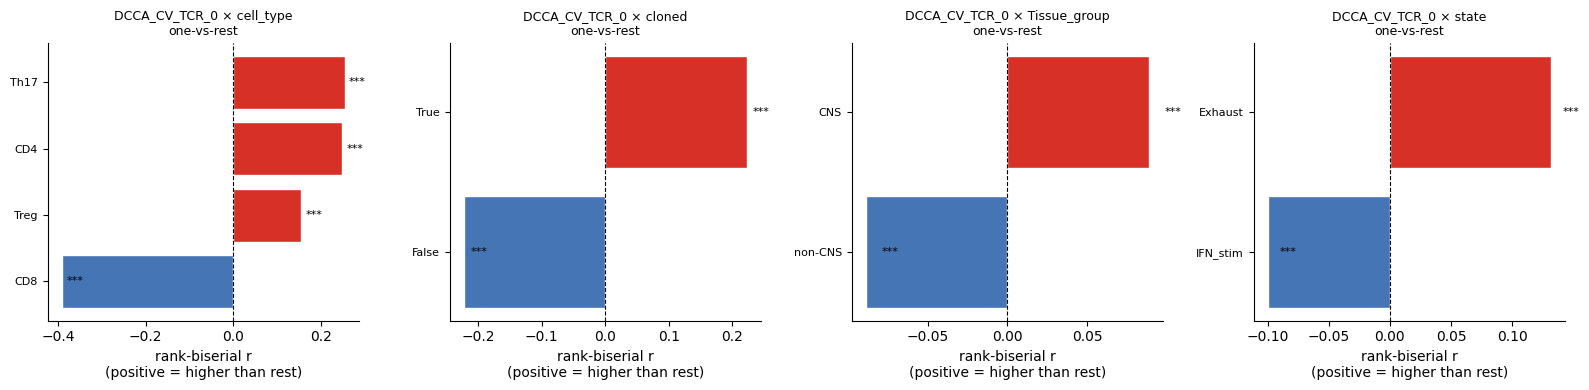

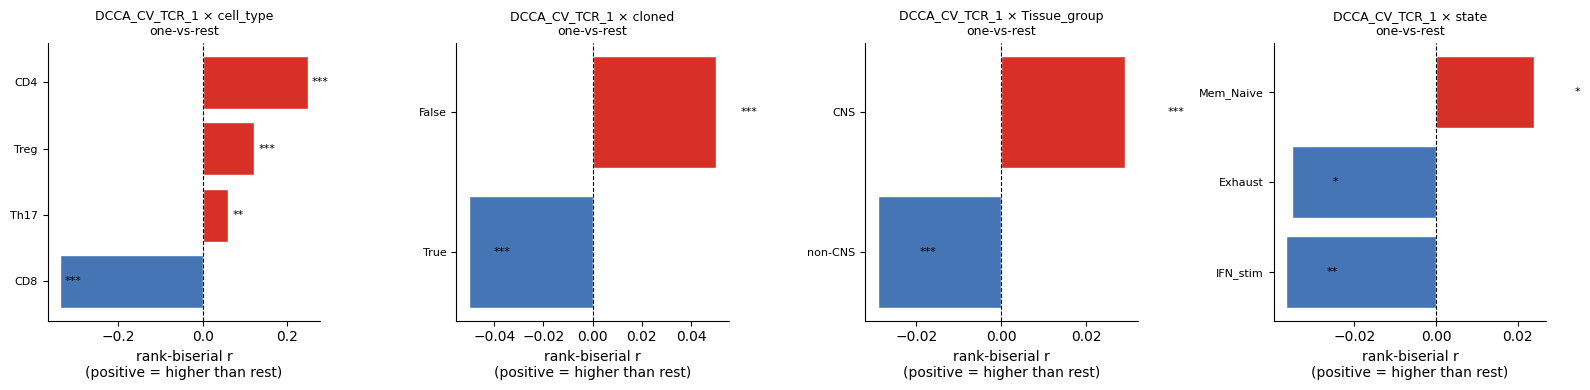

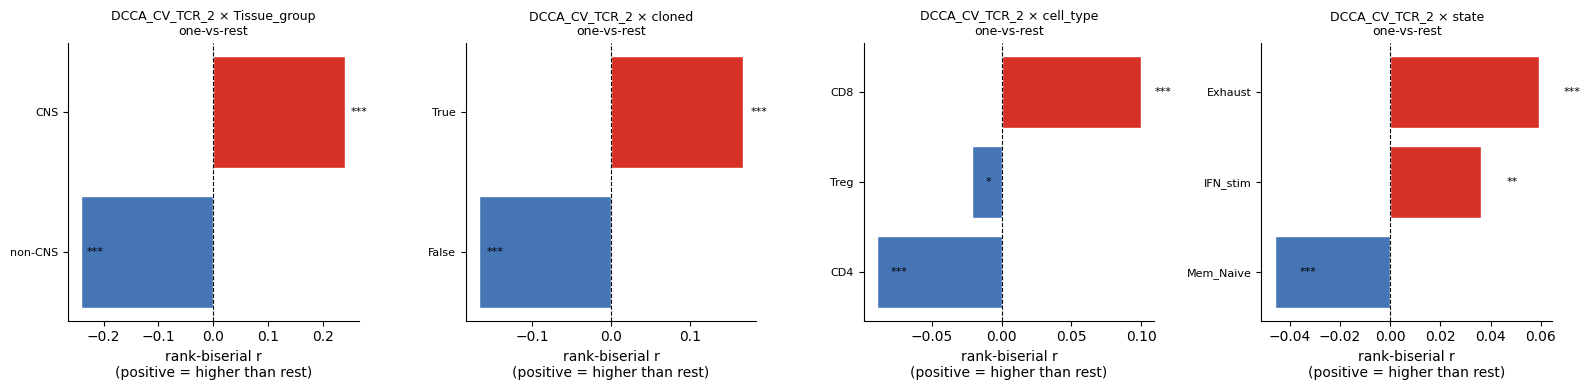

In [75]:
for i in range(dim_cca):
    col = CV_from + str(i)
    sub = df_ovr[
        (df_ovr['cv'] == col) & (df_ovr['pval_fdr'] < 0.05)
    ]

    if sub.empty:
        continue

    sig_cols = sub['obs_col'].unique()
    fig, axes = plt.subplots(1, len(sig_cols),
                              figsize=(4 * len(sig_cols), 4))
    if len(sig_cols) == 1:
        axes = [axes]

    for ax, c in zip(axes, sig_cols):
        plot_df = sub[sub['obs_col'] == c].sort_values('rbc')

        colors = ['#d73027' if v > 0 else '#4575b4'
                  for v in plot_df['rbc']]

        ax.barh(range(len(plot_df)), plot_df['rbc'],
                color=colors, edgecolor='white')
        ax.set_yticks(range(len(plot_df)))
        ax.set_yticklabels(plot_df['category'], fontsize=8)
        ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
        ax.set_xlabel('rank-biserial r\n(positive = higher than rest)')
        ax.set_title(f'{col} × {c}\none-vs-rest', fontsize=9)

        # mark FDR significance
        for j, (_, row) in enumerate(plot_df.iterrows()):
            stars = ('***' if row.pval_fdr < 0.001 else
                     '**'  if row.pval_fdr < 0.01  else
                     '*'   if row.pval_fdr < 0.05  else '')
            ax.text(row.rbc + 0.01, j, stars, va='center', fontsize=8)

        ax.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    plt.savefig(f'{col}_ovr.pdf', bbox_inches='tight')
    plt.show()

# Old Correlation: CV scores vs tissue / cell-state scores

In [76]:
import seaborn as sns

top_n      = 20
rg_method  = 'wilcoxon'

# CNS marker genes
sc.tl.rank_genes_groups(mdata['gex'], groupby='tissue', groups=['CNS'], reference='rest',
                        n_genes=top_n, method=rg_method)
rank_df   = sc.get.rank_genes_groups_df(mdata['gex'], None)
CNS_HVGs  = rank_df['names'].tolist()
sc.tl.score_genes(mdata['gex'], gene_list=CNS_HVGs, score_name='CNS_score')

# Spleen marker genes
sc.tl.rank_genes_groups(mdata['gex'], groupby='tissue', groups=['Spleen'], reference='rest',
                        n_genes=top_n, method=rg_method)
rank_df_spl = sc.get.rank_genes_groups_df(mdata['gex'], None)
SPL_HVGs    = rank_df_spl['names'].tolist()
sc.tl.score_genes(mdata['gex'], gene_list=SPL_HVGs, score_name='SPL_score')

In [77]:
cv_obs_name = [f'CV_score_{i}' for i in range(dim_cca)]
scores      = ['CD4score', 'CD8score', 'Tregscore', 'Th17score',
               'IFN_stimscore', 'Activationscore', 'Exhaustscore', 'Mem_Naivescore',
               'CNS_score', 'SPL_score']
scores      = [s for s in scores if s in mdata['gex'].obs.columns]

corr_matrix_obs = TCR_embedings.pearson_corr(mdata['gex'], cv_obs_name, scores, var_type='obs')

plt.figure(figsize=(8, 3))
sns.heatmap(corr_matrix_obs[scores], annot=True, cmap='coolwarm', center=0,
            vmin=-1, vmax=1, fmt='.3f', cbar_kws={'label': 'Pearson r'})
plt.title('CV scores vs cell-state scores (all cells)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

KeyError: 'CV_score_0'

In [ ]:
# Repeat on test set only
corr_matrix_test = TCR_embedings.pearson_corr(
    mdata[test_mask]['gex'], cv_obs_name, scores, var_type='obs'
)

plt.figure(figsize=(8, 3))
sns.heatmap(corr_matrix_test[scores], annot=True, cmap='coolwarm', center=0,
            vmin=-1, vmax=1, fmt='.3f', cbar_kws={'label': 'Pearson r'})
plt.title('CV scores vs cell-state scores (test set)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Correlation with marker genes
marker_genes = ['Cd4', 'Cd8a', 'Cd8b1', 'Cd28', 'Foxp3', 'Ccr6',
                'Ptprc', 'Ikzf2', 'Rtkn2', 'Klrg1', 'Isg15', 'Icos', 'Pdcd1', 'Ccr7']
marker_genes = [g for g in marker_genes if g in mdata['gex'].var_names]

corr_matrix_genes = TCR_embedings.pearson_corr(
    mdata['gex'], cv_obs_name, marker_genes, var_type='gene'
)

plt.figure(figsize=(8, 3))
sns.heatmap(corr_matrix_genes, annot=True, cmap='coolwarm', center=0,
            vmin=-1, vmax=1, fmt='.3f', cbar_kws={'label': 'Pearson r'})
plt.title('CV scores vs marker gene expression')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## DEGs in high-CV cells

In [ ]:
top_n = 20
for i in range(dim_cca):
    tmp_col = f'CV_score_{i}_high_cat'
    sc.tl.rank_genes_groups(
        mdata['gex'], groupby=tmp_col, reference='rest',
        n_genes=top_n, method='logreg'
    )
    sc.pl.rank_genes_groups_dotplot(mdata['gex'], n_genes=top_n, groupby=tmp_col,
                                    title=f'DEGs: {tmp_col}')

# Logistic regression: CNS vs non-CNS using TCR features

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

# Binary label: CNS vs rest
y = (mdata['gex'].obs['tissue'] == 'CNS').astype(int)

train_mask_lr = mdata.obs['set'] == 'train'
test_mask_lr  = mdata.obs['set'] == 'test'

X_train = view_tcr[train_mask_lr]
X_test  = view_tcr[test_mask_lr]
y_train = y[train_mask_lr]
y_test  = y[test_mask_lr]

lr_model = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
lr_model.fit(X_train, y_train)

y_pred       = lr_model.predict(X_test)
y_pred_proba = lr_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['non-CNS', 'CNS']))
print(f"AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

mdata.uns['lr_coef']      = lr_model.coef_
mdata.uns['lr_intercept'] = lr_model.intercept_

In [ ]:
# Visualize logistic regression score on UMAP
y_train_score = pd.Series(lr_model.predict_proba(X_train)[:, 1],
                           index=mdata.obs.index[train_mask_lr])
y_test_score  = pd.Series(y_pred_proba, index=mdata.obs.index[test_mask_lr])
TCR_logit_score = pd.concat([y_train_score, y_test_score]).reindex(mdata.obs.index)

mdata['gex'].obs['TCR_logit_score'] = TCR_logit_score.values
sc.pl.embedding(
    mdata['gex'], basis=gene_Umap, neighbors_key=neighbors_key,
    color='TCR_logit_score', ncols=1
)

# Save

In [ ]:
import anndata as ad
ad.settings.allow_write_nullable_strings = True
# mdata.write(f'{filename}_singlets_CVscores.h5mu')
# print('Saved:', f'{filename}_singlets_CVscores.h5mu')

In [ ]:
mdata